## DSBDA Project: 🚕 Taxi Demand Prediction

#### 1.Data Loading and Detailing

In [3]:
import pandas as pd
df=pd.read_csv("trip_data.csv")

In [4]:
len(df)

12748986

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12748986 entries, 0 to 12748985
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.8+ GB


In [6]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [7]:
df.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274898e+07,1.274899e+07
mean,1.521437e+00,1.681491e+00,1.345913e+01,-7.256184e+01,3.997282e+01,1.036901e+00,-7.260904e+01,3.999961e+01,1.386712e+00,1.190566e+01,3.082790e-01,4.977986e-01,1.853814e+00,2.434984e-01,2.831431e-01,1.510829e+01
std,4.995402e-01,1.337924e+00,9.844094e+03,1.012510e+01,5.578691e+00,6.732240e-01,9.966037e+00,5.487742e+00,4.988611e-01,1.030254e+01,5.916643e-01,3.534229e-02,1.106432e+03,1.527171e+00,6.908633e-02,1.106503e+03
min,1.000000e+00,0.000000e+00,0.000000e+00,-1.219258e+02,0.000000e+00,1.000000e+00,-7.401667e+02,-9.029157e+00,1.000000e+00,-4.500000e+02,-7.900000e+01,-5.000000e-01,-9.242000e+01,-2.600000e+01,0.000000e+00,-4.503000e+02
25%,1.000000e+00,1.000000e+00,1.000000e+00,-7.399168e+01,4.073554e+01,1.000000e+00,-7.399120e+01,4.073436e+01,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.160000e+00
50%,2.000000e+00,1.000000e+00,1.680000e+00,-7.398160e+01,4.075314e+01,1.000000e+00,-7.397976e+01,4.075362e+01,1.000000e+00,9.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01
75%,2.000000e+00,2.000000e+00,3.000000e+00,-7.396662e+01,4.076757e+01,1.000000e+00,-7.396246e+01,4.076880e+01,2.000000e+00,1.350000e+01,5.000000e-01,5.000000e-01,2.060000e+00,0.000000e+00,3.000000e-01,1.630000e+01
max,2.000000e+00,9.000000e+00,1.542000e+07,7.866265e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,5.000000e+00,4.008000e+03,9.999900e+02,5.000000e-01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06


#### 2. Data Pre-Processing

In [8]:
df.duplicated().any()

True

In [9]:
df.duplicated().sum()

383

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

0

In [12]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RateCodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    3
total_amount             0
dtype: int64

In [13]:
#Object to datetime conversion
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')


In [14]:
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day'] = df['tpep_pickup_datetime'].dt.day
df['month'] = df['tpep_pickup_datetime'].dt.month
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
# Trip duration (important feature)
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60  # in minutes

# Speed feature
df['speed'] = df['trip_distance'] / (df['trip_duration'] + 1)

# Peak hour feature
df['is_peak'] = df['hour'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)

# Location-based clustering (rounding coordinates)
df['pickup_latitude'] = df['pickup_latitude'].round(2)
df['pickup_longitude'] = df['pickup_longitude'].round(2)



In [15]:
# Remove invalid values
df = df[
    (df['trip_distance'] > 0) &
    (df['trip_duration'] > 0) &
    (df['pickup_latitude'] != 0) &
    (df['pickup_longitude'] != 0)
]


In [16]:
df['demand'] = 1

df = df.groupby([
    'hour','day','month','day_of_week',
    'is_peak','pickup_latitude','pickup_longitude'
]).agg({
    'demand':'sum',
    'trip_distance':'mean',
    'trip_duration':'mean',
    'speed':'mean',
    'passenger_count':'mean',
    'fare_amount':'mean'
}).reset_index()

print(df.head())

   hour  day  month  day_of_week  is_peak  pickup_latitude  pickup_longitude  \
0     0    1      1            3        0            40.62            -74.03   
1     0    1      1            3        0            40.62            -73.97   
2     0    1      1            3        0            40.63            -74.03   
3     0    1      1            3        0            40.63            -74.02   
4     0    1      1            3        0            40.63            -73.96   

   demand  trip_distance  trip_duration     speed  passenger_count  \
0       3       6.776667      15.038889  0.340320              2.0   
1       1      22.120000      42.733333  0.505793              1.0   
2       1       8.780000      17.066667  0.485978              1.0   
3       1       1.100000       5.833333  0.160976              1.0   
4       1       6.820000      29.433333  0.224096              4.0   

   fare_amount  
0    20.733333  
1    61.500000  
2    26.000000  
3     6.000000  
4    25.00000

In [25]:
high_demand_df = df[df['demand'] > 30]
high_demand_df.head()

,hour,day,month,day_of_week,is_peak,pickup_latitude,pickup_longitude,demand,trip_distance,trip_duration,speed,passenger_count,fare_amount
11,0,1,1,3,0,40.64,-73.78,71,13.896479,25.426995,0.528314,1.661972,38.801549
21,0,1,1,3,0,40.65,-73.79,39,12.221538,23.976068,0.496456,1.538462,37.761538
22,0,1,1,3,0,40.65,-73.78,86,14.753953,25.698643,0.556241,1.802326,41.426744
33,0,1,1,3,0,40.67,-73.97,33,4.110606,17.750000,0.211436,1.515152,16.260606
46,0,1,1,3,0,40.68,-73.98,92,3.868696,15.494384,0.217942,1.663043,15.018478


#### 3. Data Splitting

In [17]:
from sklearn.model_selection import train_test_split
import numpy as np
X = df.drop('demand', axis=1)
y = df['demand']

# Log transform log(1+y) (reduces MAE significantly thereby increases models Accuracy)
y = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### 4. Model Training

In [18]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### 5. Model Evaluation

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

# Convert back from log
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(" MAE:", mae)
print(" R2 Score:", r2)

 MAE: 14.439541142142183
 R2 Score: 0.9671561919861114


#### 6. To save and load trained machine learning models.

In [20]:
import joblib

joblib.dump(model, "xgboost_taxi_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [21]:
def predict_demand(input_dict):
    data = pd.DataFrame([input_dict])
    pred = model.predict(data)
    return int(np.expm1(pred[0]))

#### 7.Model Testing

In [22]:


sample_input = {
    'hour': 10,
    'day': 15,
    'month': 6,
    'day_of_week': 2,
    'is_peak': 0,
    'pickup_latitude': 40.75,
    'pickup_longitude': -73.98,
    'trip_distance': 3.5,
    'trip_duration': 12,
    'speed': 3.5/13,
    'passenger_count': 2,
    'fare_amount': 10
}

print("Predicted Demand:", predict_demand(sample_input))

Predicted Demand: 31


In [23]:
sample_input = {
    'hour': 18,                
    'day': 22,
    'month': 8,
    'day_of_week': 4,          
    'is_peak': 1,
    'pickup_latitude': 40.78,   
    'pickup_longitude': -73.95,
    'trip_distance': 8.0,       
    'trip_duration': 30,        
    'speed': 8.0/31,
    'passenger_count': 3,
    'fare_amount': 25           # Higher fare
}
print("Predicted Demand:", predict_demand(sample_input))

Predicted Demand: 5


In [28]:
sample_input = {
    'hour': 0,
    'day': 1,
    'month': 1,
    'day_of_week': 3,
    'is_peak': 0,
    'pickup_latitude': 40.64,
    'pickup_longitude': -73.78,
    'trip_distance': 13.896479,
    'trip_duration': 25.426995,
    'speed': 0.528314,
    'passenger_count': 1.661972,
    'fare_amount': 38.801549
}
print("Predicted Demand:", predict_demand(sample_input))

Predicted Demand: 79


#### 8. Visualization

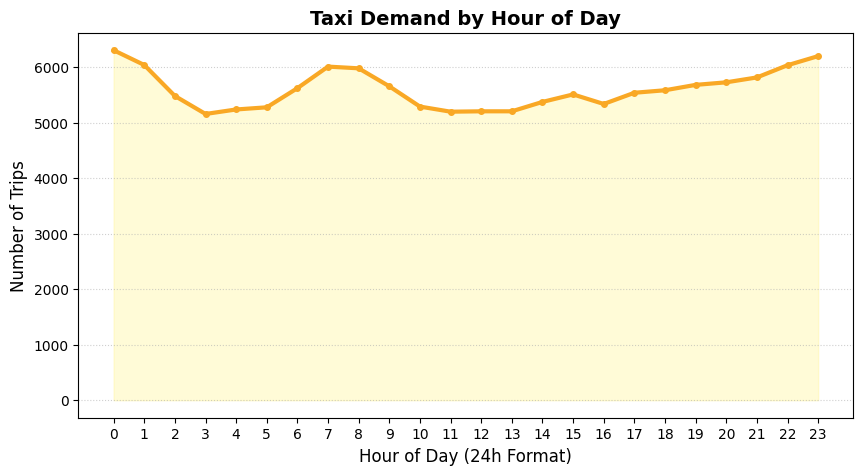

In [26]:
import matplotlib.pyplot as plt

# Grouping the data
hourly_demand = df.groupby('hour').size()

plt.figure(figsize=(10, 5))

# Plotting the line with a 'Taxi Gold' color
# We use a thicker line (linewidth) for better visibility
hourly_demand.plot(kind='line', color='#F9A825', linewidth=3, marker='o', markersize=4)

# Optional: Fill the area under the curve for a more professional 'demand' look
plt.fill_between(hourly_demand.index, hourly_demand.values, color='#FFF59D', alpha=0.4)

plt.title("Taxi Demand by Hour of Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day (24h Format)", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

# Set x-ticks to show every hour for clarity
plt.xticks(range(0, 24))
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.show()

The graph shows that taxi demand varies significantly throughout the day. Demand is relatively high during late night hours (around 12 AM–2 AM), likely due to nightlife and late travel activities. It then drops sharply in the early morning hours (around 3 AM–5 AM), indicating minimal travel during this period.

A noticeable increase in demand is observed during the morning hours (6 AM–9 AM), which corresponds to office commute time. After a slight dip during mid-day, demand gradually rises again in the afternoon.

The highest demand is observed during evening hours (6 PM–11 PM), representing peak travel time due to office return, shopping, and social activities.

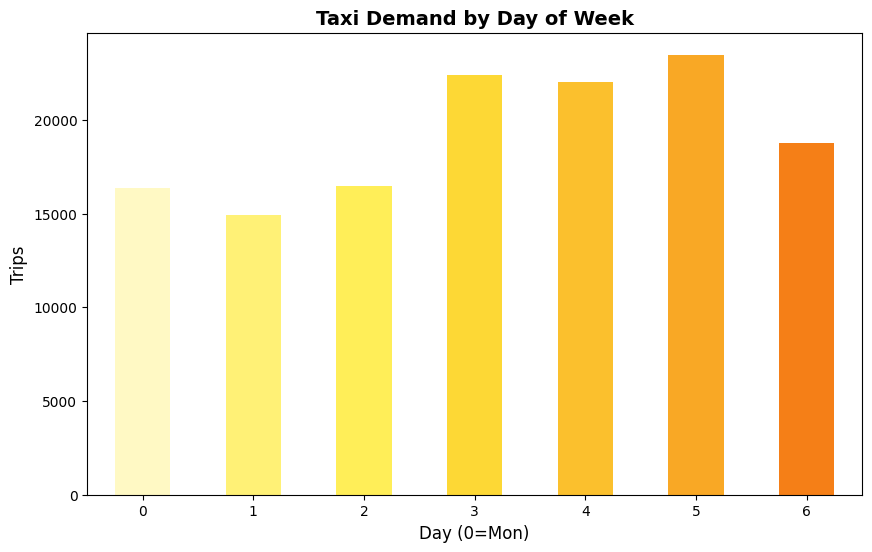

In [ ]:
import matplotlib.pyplot as plt

# Grouping the data
dow_demand = df.groupby('day_of_week').size()


yellow_shades = ['#FFF9C4', '#FFF176', '#FFEE58', '#FDD835', '#FBC02D', '#F9A825', '#F57F17']

plt.figure(figsize=(10, 6))
dow_demand.plot(kind='bar', color=yellow_shades)

plt.title("Taxi Demand by Day of Week", fontsize=14, fontweight='bold')
plt.xlabel("Day (0=Mon)", fontsize=12)
plt.ylabel("Trips", fontsize=12)
plt.xticks(rotation=0) # Keeps day labels horizontal for better readability


plt.show()

The graph illustrates the variation in taxi demand across different days of the week. Taxi demand is comparatively lower at the beginning of the week, particularly on Monday and Tuesday. As the week progresses, the number of trips gradually increases.

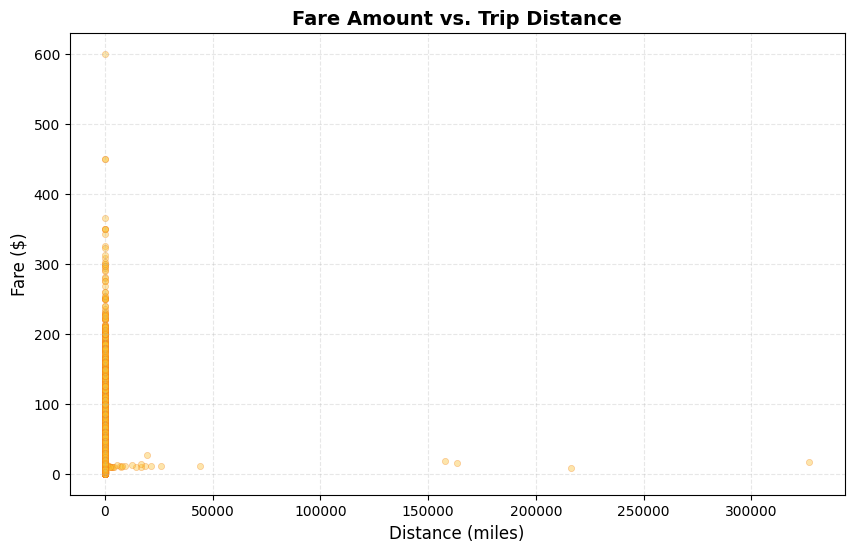

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Using a warm 'Taxi Yellow' (#FBC02D)
# alpha=0.5 helps visualize density where points overlap
# edgecolors and linewidths add definition to each point
plt.scatter(df['trip_distance'], df['fare_amount'], 
            color='#FBC02D', 
            alpha=0.4, 
            edgecolors='#F57F17', 
            linewidths=0.5,
            s=20) # 's' controls the size of the dots

plt.title("Fare Amount vs. Trip Distance", fontsize=14, fontweight='bold')
plt.xlabel("Distance (miles)", fontsize=12)
plt.ylabel("Fare ($)", fontsize=12)

# Adding a light grid for better readability
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

The scatter plot shows the relationship between trip distance and fare amount. In general, there is a positive relationship, where the fare tends to increase as the trip distance increases. This indicates that fare pricing is largely dependent on the distance traveled.

However, the plot also reveals a high concentration of trips at shorter distances with varying fare values. Additionally, there are several extreme outliers where either the distance or fare is unusually high or low, which may represent data inconsistencies or rare cases.

The spread in fare values for similar distances suggests that other factors such as traffic conditions, waiting time, and additional charges also influence the total fare.

In [ ]:
import numpy as np

# Convert back from log scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

def categorize(d):
    if d < 20:
        return "Low"
    elif d < 75:
        return "Moderate"
    else:
        return "High"

y_test_cat = [categorize(val) for val in y_test_actual]
y_pred_cat = [categorize(val) for val in y_pred_actual]

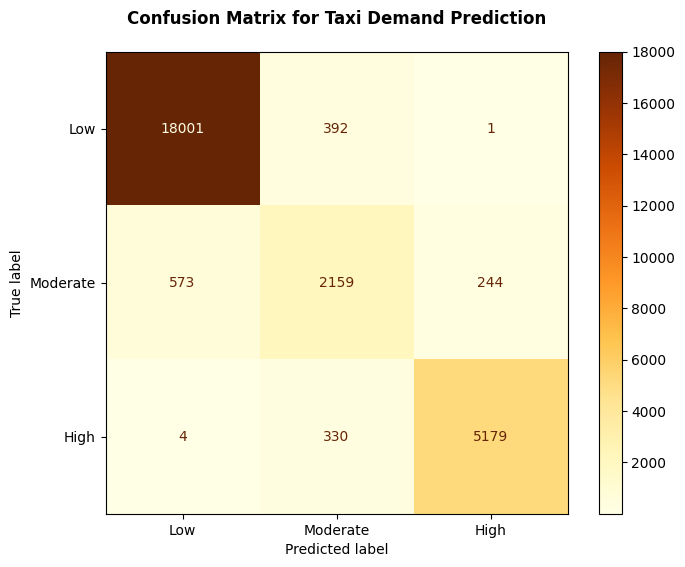

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define labels
labels = ["Low", "Moderate", "High"]

# Generate the confusion matrix
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=labels)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Use cmap='YlOrBr' for the yellow shades
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlOrBr', ax=ax)

plt.title("Confusion Matrix for Taxi Demand Prediction", pad=20, fontweight='bold')
plt.show()

### Model Performance Evaluation: Confusion Matrix
The confusion matrix illustrates the performance of the taxi demand classification model across three levels: Low, Moderate, and High.

High Accuracy on "Low" Demand: The model is exceptionally good at identifying low-demand periods, correctly predicting 18,001 instances with almost zero "Low" vs. "High" confusion.

Strong Diagonal Alignment: The majority of predictions fall along the diagonal (top-left to bottom-right), indicating that the predicted labels consistently match the true labels.

Minor Class Overlap: * There is some slight confusion between Moderate and High demand (244 cases predicted as High when they were Moderate, and 330 vice versa).

The model occasionally underestimates "Moderate" demand as "Low" (573 instances).

Overall Reliability: The model shows a strong ability to distinguish between extreme demand states (Low vs. High), which is critical for operational planning and fleet distribution.